In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import os, sys, glob, json, random, time, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

# Quick install (usually already present on Kaggle, kept here just in case)
!pip install -q timm scikit-learn grad-cam --no-deps 2>/dev/null || true

Torch: 2.10.0+cu128 | CUDA available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(root, "->", len(files), "files", "| sample:", files[0] if files else "")

/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/val/2 -> 1399 files | sample: 24734_left-600.jpg
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/val/0 -> 1520 files | sample: 20060530_51279_0100_PP.png
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/val/3 -> 1278 files | sample: 36190_right-600-HBF.jpg
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/val/1 -> 1305 files | sample: 29156_left-600-HB.jpg
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/val/4 -> 1294 files | sample: 25422_left-600.jpg
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/test/2 -> 1965 files | sample: 20170613164132693.jpg
/kaggle/input/datasets/sehastrajits/fundus-aptosddridirdeyepacsmessidor/split_dataset/test/0 -> 2650 files | sample: 7283_right-600.jpg
/kaggle/input/datasets/sehastrajit

In [3]:
# ============================================================
# CELL 2 (FAST VERSION): Hardcoded dataset paths — no slow glob
# ============================================================
import os

# --- APTOS 2019 (primary training set) ---
APTOS_ROOT = "/kaggle/input/datasets/mariaherrerot/aptos2019"
aptos_csv = os.path.join(APTOS_ROOT, "train_1.csv")
aptos_img_dir = os.path.join(APTOS_ROOT, "train_images", "train_images")

# --- IDRiD (Indian-context validation + explainability ground truth) ---
IDRID_ROOT = "/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset"

idrid_grading_csv = os.path.join(
    IDRID_ROOT, "B.%20Disease%20Grading", "B. Disease Grading",
    "2. Groundtruths", "a. IDRiD_Disease Grading_Training Labels.csv"
)
idrid_img_dir = os.path.join(
    IDRID_ROOT, "B.%20Disease%20Grading", "B. Disease Grading",
    "1. Original Images", "a. Training Set"
)
idrid_seg_root = os.path.join(
    IDRID_ROOT, "A.%20Segmentation", "A. Segmentation",
    "2. All Segmentation Groundtruths", "a. Training Set"
)

# --- Verify everything exists before moving on ---
paths_to_check = {
    "APTOS csv": aptos_csv,
    "APTOS image dir": aptos_img_dir,
    "IDRiD grading csv": idrid_grading_csv,
    "IDRiD image dir": idrid_img_dir,
    "IDRiD seg root": idrid_seg_root,
}
for name, p in paths_to_check.items():
    status = "✅ FOUND" if os.path.exists(p) else "❌ MISSING"
    print(f"{status}  {name}: {p}")

✅ FOUND  APTOS csv: /kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv
✅ FOUND  APTOS image dir: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images
✅ FOUND  IDRiD grading csv: /kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/B.%20Disease%20Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv
✅ FOUND  IDRiD image dir: /kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/B.%20Disease%20Grading/B. Disease Grading/1. Original Images/a. Training Set
✅ FOUND  IDRiD seg root: /kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set


In [4]:
# ============================================================
# CELL 3: Load labels, check class distribution
# ============================================================
import numpy as np
import os

df = pd.read_csv(aptos_csv)
print("Columns found:", df.columns.tolist())

# Auto-detect id/label columns (works even if names differ from standard APTOS)
id_col = "id_code" if "id_code" in df.columns else df.columns[0]
label_col = "diagnosis" if "diagnosis" in df.columns else df.columns[1]
df = df.rename(columns={id_col: "id_code", label_col: "diagnosis"})

def resolve_img_path(id_code):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = os.path.join(aptos_img_dir, f"{id_code}{ext}")
        if os.path.exists(p):
            return p
    return os.path.join(aptos_img_dir, f"{id_code}.png")

df["path"] = df["id_code"].apply(resolve_img_path)
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
print(f"Loaded {len(df)} labeled images")
print(df["diagnosis"].value_counts().sort_index())

CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df["diagnosis"], random_state=SEED
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}")

class_counts = df["diagnosis"].value_counts().sort_index().values
class_weights = (1.0 / class_counts)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights.cpu().numpy().round(3))

Columns found: ['id_code', 'diagnosis']
Loaded 2930 labeled images
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64
Train: 2490  Val: 440
Class weights: [0.217 1.039 0.386 2.025 1.333]


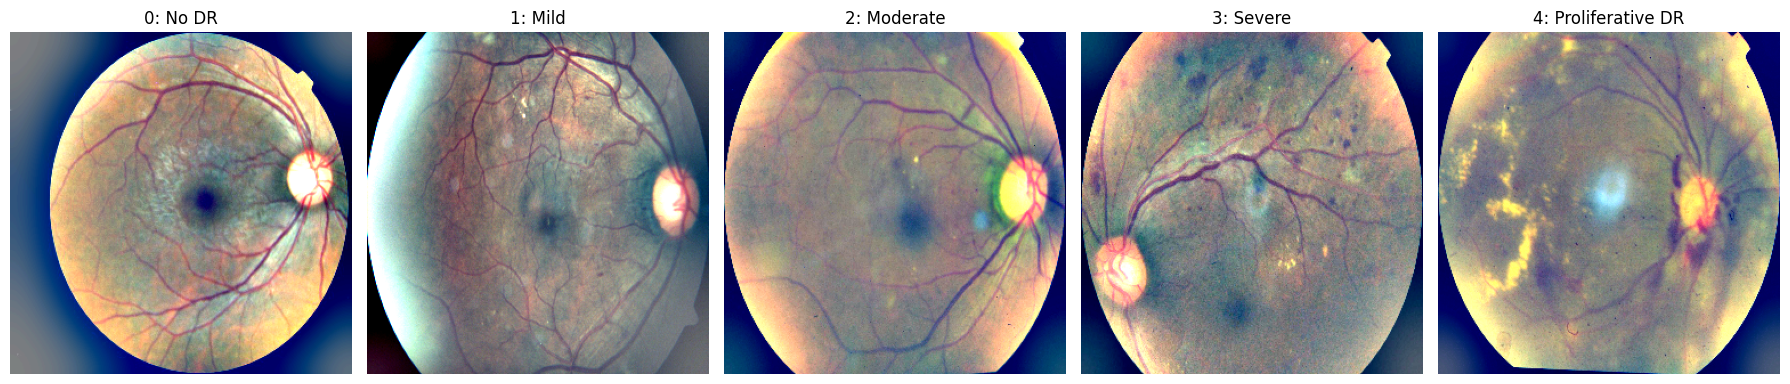

In [5]:
# ============================================================
# CELL 4: Retina preprocessing utilities
# ============================================================
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 300

def crop_black_border(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def ben_graham_preprocess(img, sigma_frac=10):
    sigma = img.shape[1] / sigma_frac
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)

def load_and_preprocess(path, size=IMG_SIZE, apply_contrast=True):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_black_border(img)
    img = cv2.resize(img, (size, size))
    if apply_contrast:
        img = ben_graham_preprocess(img)
    return img

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for cls in range(5):
    subset = df[df["diagnosis"] == cls]
    if len(subset) == 0:
        axes[cls].set_title(f"{cls}: no samples"); axes[cls].axis("off"); continue
    row = subset.iloc[0]
    img = load_and_preprocess(row["path"])
    axes[cls].imshow(img)
    axes[cls].set_title(f"{cls}: {CLASS_NAMES[cls]}")
    axes[cls].axis("off")
plt.tight_layout(); plt.show()

In [6]:
# ============================================================
# CELL 5: PyTorch Dataset + augmentation
# ============================================================
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class DRDataset(Dataset):
    def __init__(self, dataframe, transform, size=IMG_SIZE):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.size = size
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_and_preprocess(row["path"], size=self.size)
        img = self.transform(img)
        return img, int(row["diagnosis"])

BATCH_SIZE = 32  # OOM आए तो 16 कर दें
train_ds = DRDataset(train_df, train_tfms)
val_ds   = DRDataset(val_df, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Train batches: 78  Val batches: 14


In [7]:
# ============================================================
# CELL 6: Model definition (EfficientNet-B0)
# ============================================================
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_model(num_classes=5, freeze_backbone=True):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    return model.to(DEVICE)

model = build_model(freeze_backbone=True)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Trainable params: 6,405
Total params:     4,013,953


In [8]:
# ============================================================
# CELL 7: Training loop — mixed precision + QWK tracking
# ============================================================
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import cohen_kappa_score, accuracy_score
import time

criterion = nn.CrossEntropyLoss(weight=class_weights)
scaler = GradScaler()

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(outputs.argmax(1).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, qwk, acc

def train_model(model, epochs, lr, tag=""):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_qwk = -1
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_qwk, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_qwk, val_acc = run_epoch(model, val_loader)
        scheduler.step()
        dt = time.time() - t0
        print(f"[{tag}] Epoch {epoch+1}/{epochs} ({dt:.0f}s) "
              f"train_loss={train_loss:.3f} train_qwk={train_qwk:.3f} | "
              f"val_loss={val_loss:.3f} val_qwk={val_qwk:.3f} val_acc={val_acc:.3f}")
        if val_qwk > best_qwk:
            best_qwk = val_qwk
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

# Stage 1: frozen backbone (~15-20 min)
train_model(model, epochs=4, lr=1e-3, tag="stage1-head")

# Stage 2: fine-tune everything (~1-1.5 hr)
for p in model.parameters():
    p.requires_grad = True
train_model(model, epochs=8, lr=1e-4, tag="stage2-finetune")

print("Best model saved to /kaggle/working/best_model.pth")

[stage1-head] Epoch 1/4 (497s) train_loss=1.370 train_qwk=0.575 | val_loss=1.172 val_qwk=0.791 val_acc=0.689
[stage1-head] Epoch 2/4 (455s) train_loss=1.150 train_qwk=0.704 | val_loss=1.116 val_qwk=0.846 val_acc=0.743
[stage1-head] Epoch 3/4 (449s) train_loss=1.085 train_qwk=0.740 | val_loss=1.075 val_qwk=0.837 val_acc=0.723
[stage1-head] Epoch 4/4 (445s) train_loss=1.055 train_qwk=0.735 | val_loss=1.068 val_qwk=0.832 val_acc=0.718
[stage2-finetune] Epoch 1/8 (459s) train_loss=0.961 train_qwk=0.776 | val_loss=0.882 val_qwk=0.865 val_acc=0.764
[stage2-finetune] Epoch 2/8 (456s) train_loss=0.806 train_qwk=0.841 | val_loss=0.800 val_qwk=0.899 val_acc=0.793
[stage2-finetune] Epoch 3/8 (462s) train_loss=0.734 train_qwk=0.870 | val_loss=0.793 val_qwk=0.902 val_acc=0.768
[stage2-finetune] Epoch 4/8 (454s) train_loss=0.669 train_qwk=0.870 | val_loss=0.763 val_qwk=0.923 val_acc=0.816
[stage2-finetune] Epoch 5/8 (452s) train_loss=0.600 train_qwk=0.894 | val_loss=0.758 val_qwk=0.921 val_acc=0.820

Overall Validation Accuracy : 81.59%
Quadratic Weighted Kappa    : 0.923

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.98      0.98      0.98       216
            Mild       0.56      0.69      0.62        45
        Moderate       0.79      0.68      0.73       121
          Severe       0.37      0.61      0.46        23
Proliferative DR       0.77      0.57      0.66        35

        accuracy                           0.82       440
       macro avg       0.69      0.71      0.69       440
    weighted avg       0.83      0.82      0.82       440



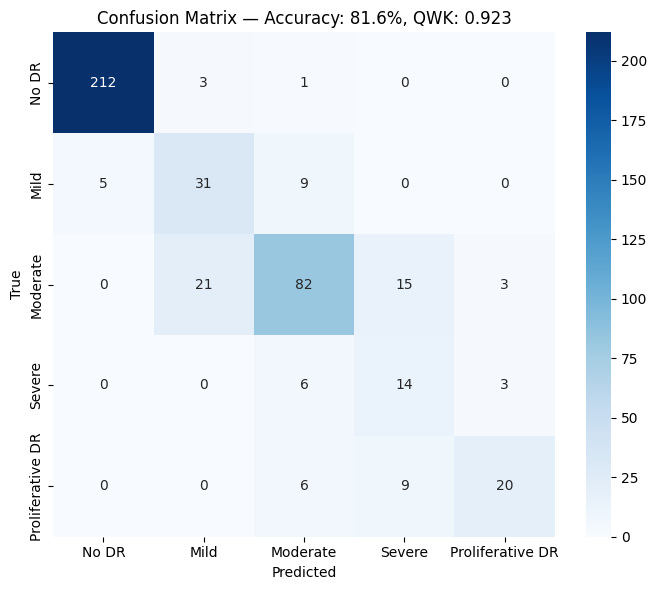


Per-class accuracy:
  No DR               : 98.1%
  Mild                : 68.9%
  Moderate            : 67.8%
  Severe              : 60.9%
  Proliferative DR    : 57.1%


In [9]:
# ============================================================
# CELL 7.5: Full evaluation report (accuracy + confusion matrix)
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

overall_acc = accuracy_score(all_labels, all_preds)
overall_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print(f"Overall Validation Accuracy : {overall_acc*100:.2f}%")
print(f"Quadratic Weighted Kappa    : {overall_qwk:.3f}")
print()
print("Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
    zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
            yticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix — Accuracy: {overall_acc*100:.1f}%, QWK: {overall_qwk:.3f}")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"  {CLASS_NAMES[i]:20s}: {acc*100:.1f}%")

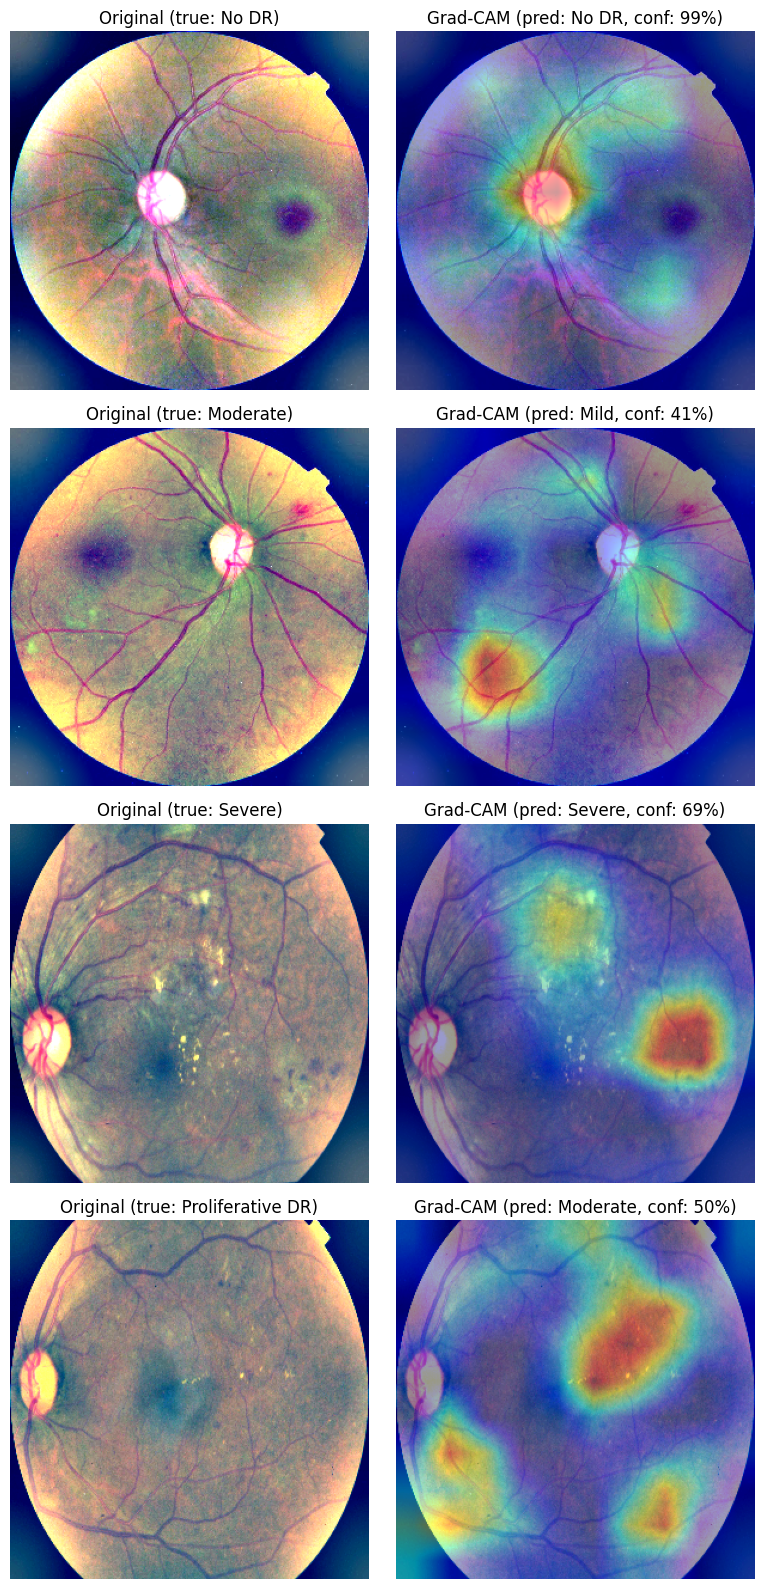

In [10]:
# ============================================================
# CELL 8: Grad-CAM
# ============================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(DEVICE)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx, F.softmax(output, dim=1)[0].detach().cpu().numpy()

target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

def overlay_heatmap(orig_img, cam, alpha=0.4):
    cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(orig_img, 1 - alpha, heatmap, alpha, 0)
    return overlay, cam_resized

def predict_with_gradcam(path, size=IMG_SIZE):
    orig = load_and_preprocess(path, size=size)
    tensor = val_tfms(orig).unsqueeze(0).to(DEVICE)
    tensor.requires_grad_(True)
    cam, pred_class, probs = gradcam.generate(tensor)
    overlay, cam_resized = overlay_heatmap(orig, cam)
    return orig, overlay, pred_class, probs, cam_resized

# Sample validation images to visualize (bias toward higher-severity classes for a better demo)
fig, axes = plt.subplots(4, 2, figsize=(8, 16))
sample_rows = pd.concat([
    val_df[val_df["diagnosis"] == 0].sample(1, random_state=SEED),
    val_df[val_df["diagnosis"] == 2].sample(1, random_state=SEED),
    val_df[val_df["diagnosis"] == 3].sample(1, random_state=SEED) if len(val_df[val_df["diagnosis"] == 3]) > 0 else val_df.sample(1, random_state=SEED),
    val_df[val_df["diagnosis"] == 4].sample(1, random_state=SEED) if len(val_df[val_df["diagnosis"] == 4]) > 0 else val_df.sample(1, random_state=SEED),
])

for i, (_, row) in enumerate(sample_rows.iterrows()):
    orig, overlay, pred_class, probs, _ = predict_with_gradcam(row["path"])
    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original (true: {CLASS_NAMES[row['diagnosis']]})")
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM (pred: {CLASS_NAMES[pred_class]}, conf: {probs[pred_class]*100:.0f}%)")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_samples.png", dpi=150)
plt.show()

Found 54 segmentation-set original images
Sample: ['/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_01.jpg', '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_02.jpg', '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_03.jpg']

Grad-CAM vs lesion-mask IoU over 16 IDRiD images:
  mean=0.085, median=0.075


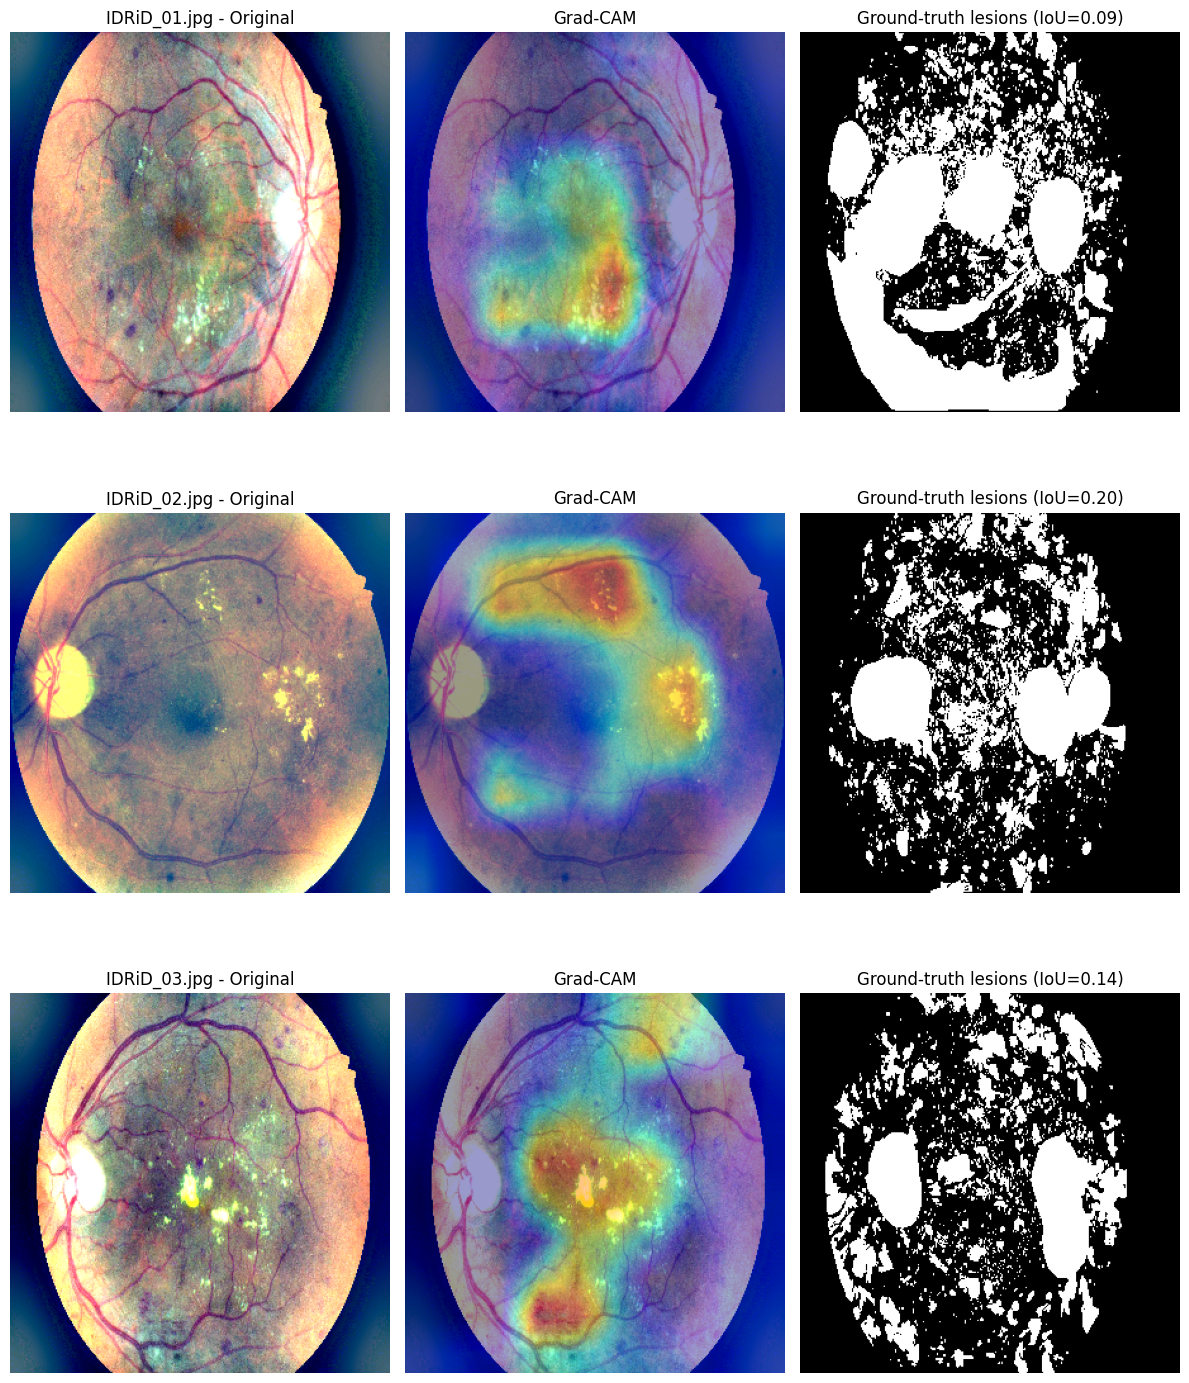

In [11]:
# ============================================================
# CELL 9 (FIXED): Grad-CAM vs IDRiD lesion masks
# Use the Segmentation task's own 54 images (not the Grading CSV),
# since Grading and Segmentation are different image subsets in IDRiD.
# ============================================================
import glob

IDRID_SEG_ORIGINAL_IMAGES = os.path.join(
    IDRID_ROOT, "A.%20Segmentation", "A. Segmentation",
    "1. Original Images", "a. Training Set"
)

seg_image_files = sorted(glob.glob(os.path.join(IDRID_SEG_ORIGINAL_IMAGES, "*.jpg")))
print(f"Found {len(seg_image_files)} segmentation-set original images")
print("Sample:", seg_image_files[:3])

def find_idrid_masks_for_image(image_id, seg_root):
    """image_id like '52' -> matches IDRiD_52_MA.tif, IDRiD_52_HE.tif, etc."""
    hits = glob.glob(os.path.join(seg_root, "**", f"*_{image_id}_*"), recursive=True)
    if not hits:
        hits = glob.glob(os.path.join(seg_root, "**", f"*IDRiD_{image_id}*"), recursive=True)
    return [h for h in hits if h.lower().endswith((".tif", ".tiff", ".png"))]

def union_lesion_mask(mask_paths, size):
    union = np.zeros((size, size), dtype=np.uint8)
    for p in mask_paths:
        m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        m = cv2.resize(m, (size, size))
        union = np.maximum(union, (m > 0).astype(np.uint8) * 255)
    return union

def cam_lesion_overlap(cam_resized, lesion_mask, threshold=0.5):
    cam_bin = (cam_resized >= threshold).astype(np.uint8)
    lesion_bin = (lesion_mask > 0).astype(np.uint8)
    intersection = np.logical_and(cam_bin, lesion_bin).sum()
    union = np.logical_or(cam_bin, lesion_bin).sum()
    return intersection / union if union > 0 else np.nan

ious = []
matched_examples = []

for img_path in seg_image_files[:20]:  # sample for speed
    fname = os.path.basename(img_path)
    # Extract numeric id from "IDRiD_52.jpg" -> "52"
    img_id = fname.replace("IDRiD_", "").replace(".jpg", "").lstrip("0") or "0"

    orig, overlay, pred_class, probs, cam_resized = predict_with_gradcam(img_path)
    mask_paths = find_idrid_masks_for_image(img_id, idrid_seg_root)
    if not mask_paths:
        continue
    lesion_mask = union_lesion_mask(mask_paths, size=IMG_SIZE)
    cam_norm = cam_resized / 255.0 if cam_resized.max() > 1 else cam_resized
    iou = cam_lesion_overlap(cam_norm, lesion_mask)
    if not np.isnan(iou):
        ious.append(iou)
        matched_examples.append((orig, overlay, lesion_mask, fname, iou))

if ious:
    print(f"\nGrad-CAM vs lesion-mask IoU over {len(ious)} IDRiD images:")
    print(f"  mean={np.mean(ious):.3f}, median={np.median(ious):.3f}")
else:
    print("Still no matches — printing mask folder sample filenames to debug:")
    print(glob.glob(os.path.join(idrid_seg_root, "**", "*.tif"), recursive=True)[:5])

# Visualize top matches
if matched_examples:
    n_show = min(3, len(matched_examples))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 5 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    for i in range(n_show):
        orig, overlay, lesion_mask, fname, iou = matched_examples[i]
        axes[i, 0].imshow(orig); axes[i, 0].set_title(f"{fname} - Original")
        axes[i, 1].imshow(overlay); axes[i, 1].set_title("Grad-CAM")
        axes[i, 2].imshow(lesion_mask, cmap="gray"); axes[i, 2].set_title(f"Ground-truth lesions (IoU={iou:.2f})")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/idrid_validation.png", dpi=150)
    plt.show()

In [12]:
# ============================================================
# CELL 10: Export model for demo
# ============================================================
import json

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()
torch.save(model.state_dict(), "/kaggle/working/dr_model_final.pth")

metadata = {
    "img_size": IMG_SIZE,
    "class_names": CLASS_NAMES,
    "mean": IMAGENET_MEAN,
    "std": IMAGENET_STD,
    "architecture": "efficientnet_b0",
}
with open("/kaggle/working/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Exported: dr_model_final.pth + model_metadata.json")
print("Ab Kaggle ke 'Output' panel se dono files download kar lein.")

Exported: dr_model_final.pth + model_metadata.json
Ab Kaggle ke 'Output' panel se dono files download kar lein.
